# Regressão Logística
Vamos aplicar os conceitos de regressão logística para o dataset [Breast Cancer](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset)

In [14]:
from sklearn.datasets import load_breast_cancer
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys
from pathlib import Path

root = Path().resolve().parent  # aponta para machine-learning/
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from classes.regression import LogisticRegression

In [15]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

True
Using GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [16]:
data =  load_breast_cancer()
N = len(data.data)
Ntrain = int(np.ceil(N*0.6))
perm = np.random.permutation(len(data.data))
X = torch.tensor(data.data, device=device).float()
X = torch.cat((X, torch.ones((X.shape[0], 1), device=device)), axis=1) 
y = torch.tensor(data.target, device=device).float()

Xtrain, ytrain = X[perm[:Ntrain]], y[perm[:Ntrain]]
Xtest, ytest = X[perm[Ntrain:]], y[perm[Ntrain:]]

In [17]:
def entropy(p):
    eps = 1e-8  # evitar log(0)
    return -(p * torch.log(p + eps) + (1 - p) * torch.log(1 - p + eps))


def split_entropy(probs, y_true):
    preds = (probs >= 0.5).float()
    ent = entropy(probs)

    correct_mask = preds == y_true
    wrong_mask = preds != y_true

    return ent[correct_mask], ent[wrong_mask]

In [18]:
def plot_entropy(correct: torch.Tensor, wrong: torch.Tensor, title: str):
    plt.figure()
    
    sns.kdeplot(correct.cpu().numpy(), label='Correct', fill=True, alpha=0.4)
    sns.kdeplot(wrong.cpu().numpy(), label='Wrong', fill=True, alpha=0.4)
    
    plt.title(title)
    plt.xlabel("Entropy")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

Implementação da estimativa de máximo a posteriori para um modelo de regressão logística com priori $\mathcal{N}(0, c I)$ com $c=100$

In [19]:
c = 100
covariance_matrix = c*torch.eye(Xtrain.shape[1])
mean = torch.zeros(Xtrain.shape[1])

In [20]:
logistic_regression_maximum_posteriori = LogisticRegression(device=device)

logistic_regression_maximum_posteriori.fit(
    Xtrain,
    ytrain,
    mode='maximum_posteriori',
    mean=mean,
    covariance_matrix=covariance_matrix,
    epochs=10000,
    lr=0.01
)

In [21]:
predictions_mp = logistic_regression_maximum_posteriori.predict(Xtest)

In [22]:
accuracy_mp = (predictions_mp == ytest).float().mean().item()

In [23]:
print(f"Accuracy (Maximum Posteriori): {accuracy_mp:.4f}")

Accuracy (Maximum Posteriori): 0.9031


In [24]:
probs_mp = logistic_regression_maximum_posteriori.sigmoid(Xtest @ logistic_regression_maximum_posteriori.theta)

In [25]:
ent_mp_correct, ent_mp_wrong = split_entropy(probs_mp, ytest)

C:\Users\Jotinha\AppData\Local\Temp\ipykernel_996\2512052775.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(correct.cpu().numpy(), label='Correct', fill=True, alpha=0.4)
C:\Users\Jotinha\AppData\Local\Temp\ipykernel_996\2512052775.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(wrong.cpu().numpy(), label='Wrong', fill=True, alpha=0.4)
C:\Users\Jotinha\AppData\Local\Temp\ipykernel_996\2512052775.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


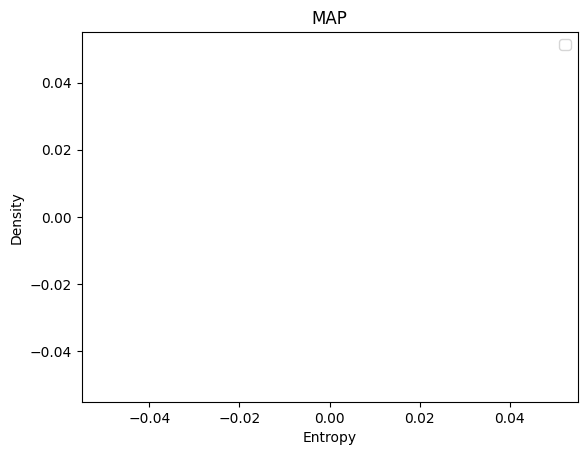

In [26]:
plot_entropy(ent_mp_correct, ent_mp_wrong, "MAP")

Implementação usando aproximação de laplace:
$$
    \ln p(\theta|D) \approx \ln p(m|D) + (\theta - m)^{\top} \nabla_\theta \ln p(m|D) + (\theta - m)^{\top} \nabla^2_\theta \ln p(m|D) (\theta - m)
$$

In [27]:
logistic_regression_laplace = LogisticRegression(device=device)

logistic_regression_laplace.fit(
    Xtrain,
    ytrain,
    mode='laplace',
    mean=mean,
    covariance_matrix=covariance_matrix,
    epochs=10000,
    lr=0.01
)

In [28]:
predictions_laplace = logistic_regression_laplace.predict(Xtest)

In [29]:
accuracy_laplace = (predictions_laplace == ytest).float().mean().item()

In [30]:
print(f"Accuracy (Laplace): {accuracy_laplace:.4f}")

Accuracy (Laplace): 0.9031


In [31]:
probs_laplace = logistic_regression_laplace.predict_proba_laplace(Xtest)

In [32]:
ent_lap_correct, ent_lap_wrong = split_entropy(probs_laplace, ytest)

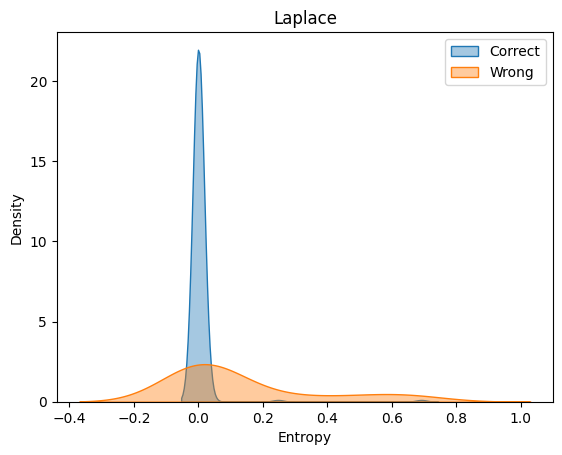

In [33]:
plot_entropy(ent_lap_correct, ent_lap_wrong, "Laplace")

Implementação da aproximação variacional com gaussiana diagonal e o truque da reparametrização

In [34]:
logistic_regression_variational = LogisticRegression(device=device)

logistic_regression_variational.fit(
    Xtrain,
    ytrain,
    mode='variational',
    mean=mean,
    covariance_matrix=covariance_matrix,
    epochs=10000,
    lr=0.01
)

In [35]:
predictions_variational = logistic_regression_variational.predict(Xtest)

In [36]:
accuracy_variational = (predictions_variational == ytest).float().mean().item()

In [37]:
print(f"Accuracy (Variational): {accuracy_variational:.4f}")

Accuracy (Variational): 0.9604


In [38]:
probs_variational = logistic_regression_variational.predict_proba_variational(Xtest)

In [39]:
ent_var_correct, ent_var_wrong = split_entropy(probs_variational, ytest)

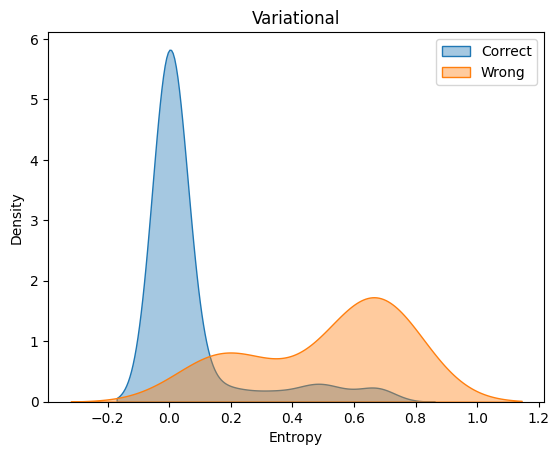

In [40]:
plot_entropy(ent_var_correct, ent_var_wrong, "Variational")